In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gc
sns.set_theme()
gc.enable()

In [2]:
instalments_data=pd.read_csv('installments_payments.csv')
instalments_data.shape

(13605401, 8)

In [3]:
instalments_data.head()

,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT
0,1054186,161674,1.0,6,-1180.0,-1187.0,6948.360,6948.360
1,1330831,151639,0.0,34,-2156.0,-2156.0,1716.525,1716.525
2,2085231,193053,2.0,1,-63.0,-63.0,25425.000,25425.000
3,2452527,199697,1.0,3,-2418.0,-2426.0,24350.130,24350.130
4,2714724,167756,1.0,2,-1383.0,-1366.0,2165.040,2160.585


In [4]:
instalments_data.isnull().sum()

SK_ID_PREV                   0
SK_ID_CURR                   0
NUM_INSTALMENT_VERSION       0
NUM_INSTALMENT_NUMBER        0
DAYS_INSTALMENT              0
DAYS_ENTRY_PAYMENT        2905
AMT_INSTALMENT               0
AMT_PAYMENT               2905
dtype: int64

In [5]:
instalments_data.describe()

,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT
count,1.360540e+07,1.360540e+07,1.360540e+07,1.360540e+07,1.360540e+07,1.360250e+07,1.360540e+07,1.360250e+07
mean,1.903365e+06,2.784449e+05,8.566373e-01,1.887090e+01,-1.042270e+03,-1.051114e+03,1.705091e+04,1.723822e+04
std,5.362029e+05,1.027183e+05,1.035216e+00,2.666407e+01,8.009463e+02,8.005859e+02,5.057025e+04,5.473578e+04
min,1.000001e+06,1.000010e+05,0.000000e+00,1.000000e+00,-2.922000e+03,-4.921000e+03,0.000000e+00,0.000000e+00
25%,1.434191e+06,1.896390e+05,0.000000e+00,4.000000e+00,-1.654000e+03,-1.662000e+03,4.226085e+03,3.398265e+03
50%,1.896520e+06,2.786850e+05,1.000000e+00,8.000000e+00,-8.180000e+02,-8.270000e+02,8.884080e+03,8.125515e+03
75%,2.369094e+06,3.675300e+05,1.000000e+00,1.900000e+01,-3.610000e+02,-3.700000e+02,1.671021e+04,1.610842e+04
max,2.843499e+06,4.562550e+05,1.780000e+02,2.770000e+02,-1.000000e+00,-1.000000e+00,3.771488e+06,3.771488e+06


### Adding Some Columns

In [12]:
'''
DAYS_PAYMENT_DIFFERENCE: if positive means that those number of days late to payment. Otherwise, those number of
days prior to deadline.
LATE_PAYMENT: 0 if timely payment, 1 if late payment
AMT_PAYMENT_DIFFERENCE: if positive, it highlights how much less the customer paid.
AMT_PAYMENT_DIFFERENCE: pct difference wrt instalment amount
MISSED_PAYMENT: 0 is customer paid more than 10% of the amount. 1 otherwise
'''
instalments_data['DAYS_PAYMENT_DIFFERENCE']=instalments_data['DAYS_ENTRY_PAYMENT']-instalments_data['DAYS_INSTALMENT']

instalments_data['LATE_PAYMENT']=0
instalments_data.loc[instalments_data['DAYS_PAYMENT_DIFFERENCE']>0, 'LATE_PAYMENT']=1

instalments_data['AMT_PAYMENT_DIFFERENCE']=instalments_data['AMT_INSTALMENT']-instalments_data['AMT_PAYMENT']
instalments_data['AMT_PAYMENT_DIFFERENCE_PCT']=instalments_data['AMT_PAYMENT_DIFFERENCE']*100/instalments_data['AMT_INSTALMENT']

instalments_data['MISSSED_PAYMENT']=0
instalments_data.loc[instalments_data['AMT_PAYMENT_DIFFERENCE_PCT']>90, 'MISSED_PAYMENT']=1

In [10]:
'''
curr_prev_table stores the unique mapping of previous loans to current loans as a dataframe
'''
curr_prev_table=instalments_data[['SK_ID_CURR', 'SK_ID_PREV']].drop_duplicates()
curr_prev_table.shape

(997752, 2)

In [13]:
instalments_data.columns.sort_values()

Index(['AMT_INSTALMENT', 'AMT_PAYMENT', 'AMT_PAYMENT_DIFFERENCE',
       'AMT_PAYMENT_DIFFERENCE_PCT', 'DAYS_ENTRY_PAYMENT', 'DAYS_INSTALMENT',
       'DAYS_PAYMENT_DIFFERENCE', 'LATE_PAYMENT', 'MISSED_PAYMENT',
       'MISSSED_PAYMENT', 'NUM_INSTALMENT_NUMBER', 'NUM_INSTALMENT_VERSION',
       'SK_ID_CURR', 'SK_ID_PREV'],
      dtype='object')

### Aggregating based on SK_ID_PREV

In [17]:
'''
other features will be aggregate directly
'''
agg1=instalments_data.groupby(by='SK_ID_PREV').agg(func={'LATE_PAYMENT': 'sum', 'MISSED_PAYMENT': 'sum',
                                                         'SK_ID_PREV': 'count'})
agg1.rename(columns={'SK_ID_PREV': 'RECORDS'}, inplace=True)
agg1.reset_index(inplace=True)
agg1.head()

,SK_ID_PREV,LATE_PAYMENT,MISSED_PAYMENT,RECORDS
0,1000001,0,0.0,2
1,1000002,0,0.0,4
2,1000003,0,0.0,3
3,1000004,0,0.0,7
4,1000005,2,1.0,11


In [18]:
'''
adding some relevant columns
'''
agg1['LATE_PAYMENT_PCT']=agg1['LATE_PAYMENT']*100/agg1['RECORDS']
agg1['MISSED_PAYMENT_PCT']=agg1['MISSED_PAYMENT']*100/agg1['RECORDS']
agg1.shape

(997752, 6)

In [20]:
'''
adding the SK_ID_CURR
'''
agg1=pd.merge(left=curr_prev_table, right=agg1, on='SK_ID_PREV')

### Aggregating based on SK_ID_CURR

In [26]:
'''
aggregating remaining columns
'''
agg2=instalments_data.groupby(by='SK_ID_CURR').agg(func={'AMT_INSTALMENT': ['min', 'max', 'median'],
                                                    'AMT_PAYMENT_DIFFERENCE': ['min', 'max', 'median', 'sum'],
                                                    'AMT_PAYMENT_DIFFERENCE_PCT': ['min', 'max', 'median'],
                                                    'DAYS_INSTALMENT': ['min', 'max', 'median'],
                                                    'DAYS_PAYMENT_DIFFERENCE': ['min', 'max', 'median', 'sum']})

agg2.columns=pd.Index(['_'.join(val) for val in agg2.columns.to_flat_index()])
agg2.reset_index(inplace=True)
agg2.shape

(339587, 18)

In [31]:
'''
second level of aggregation for previously aggregated features (based on SK_ID_PREV)
'''
temp=agg1.groupby(by='SK_ID_CURR').agg({'LATE_PAYMENT': ['min', 'max', 'median', 'sum'],
                                   'MISSED_PAYMENT': ['min', 'max', 'median', 'sum'],
                                   'RECORDS': ['min', 'max', 'median', 'sum'],
                                   'LATE_PAYMENT_PCT': 'max', 'MISSED_PAYMENT_PCT': 'max', 'SK_ID_CURR': 'count'
                                   })

temp.columns=pd.Index(['_'.join(val) for val in temp.columns.to_flat_index()])
temp['LATE_PAYMENT_PCT']=temp['LATE_PAYMENT_sum']*100/temp['RECORDS_sum']
temp['MISSED_PAYMENT_PCT']=temp['MISSED_PAYMENT_sum']*100/temp['RECORDS_sum']
temp.reset_index(inplace=True)
temp.shape

(339587, 18)

In [34]:
'''
merging both datsets
'''
agg2=pd.merge(left=agg2, right=temp, on='SK_ID_CURR')
agg2.shape

(339587, 35)

In [35]:
'''
adding target column
<main_data_id_target> contains target for each current loan
'''
main_data_id_target=pd.read_csv('application_train.csv',usecols=['SK_ID_CURR', 'TARGET']) 
agg_target=pd.merge(left=agg2, right=main_data_id_target, on='SK_ID_CURR')
agg_target.shape

(291643, 36)

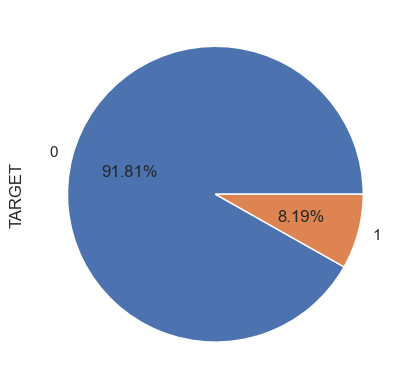

In [36]:
'''
distribution of target in the aggregated bureau data
'''
agg_target['TARGET'].value_counts().plot.pie(autopct='%1.2f%%');

In [37]:
agg_target.isnull().sum()

SK_ID_CURR                           0
AMT_INSTALMENT_min                   0
AMT_INSTALMENT_max                   0
AMT_INSTALMENT_median                0
AMT_PAYMENT_DIFFERENCE_min           8
AMT_PAYMENT_DIFFERENCE_max           8
AMT_PAYMENT_DIFFERENCE_median        8
AMT_PAYMENT_DIFFERENCE_sum           0
AMT_PAYMENT_DIFFERENCE_PCT_min       8
AMT_PAYMENT_DIFFERENCE_PCT_max       8
AMT_PAYMENT_DIFFERENCE_PCT_median    8
DAYS_INSTALMENT_min                  0
DAYS_INSTALMENT_max                  0
DAYS_INSTALMENT_median               0
DAYS_PAYMENT_DIFFERENCE_min          8
DAYS_PAYMENT_DIFFERENCE_max          8
DAYS_PAYMENT_DIFFERENCE_median       8
DAYS_PAYMENT_DIFFERENCE_sum          0
LATE_PAYMENT_min                     0
LATE_PAYMENT_max                     0
LATE_PAYMENT_median                  0
LATE_PAYMENT_sum                     0
MISSED_PAYMENT_min                   0
MISSED_PAYMENT_max                   0
MISSED_PAYMENT_median                0
MISSED_PAYMENT_sum       